In [26]:
import pandas as pd


players_df = pd.read_csv(r'C:\Users\ayele\Desktop\data (1)\archive (2)\players.csv')
appearances_df = pd.read_csv(r'C:\Users\ayele\Desktop\data (1)\archive (2)\appearances.csv')

# Merge the datasets on 'player_id' to create one rich DataFrame
df = pd.merge(appearances_df, players_df, on='player_id', how='left')

# Display the first 5 rows to verify the data loaded correctly
df.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,...,ER Sport Agency,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/aurelien-joach...,NL1,RKC Waalwijk,75000.0,600000.0
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/ruslan-abyshov...,RU1,FC Rubin Kazan,25000.0,450000.0
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/sander-puri/pr...,SC1,St. Mirren FC,100000.0,600000.0
3,2234418_73333,2234418,73333,1274,76,2012-07-05,Vegar Hedenstad,ELQ,0,0,...,TPSportManagement,https://img.a.transfermarkt.technology/portrai...,4.0,0.0,NaN,https://www.transfermarkt.co.uk/vegar-hedensta...,NO1,Vålerengens Idrettsforening,350000.0,1500000.0
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/markus-henriks...,GB1,Hull City,800000.0,5000000.0


In [27]:
# List of the 14 most relevant columns for our EDA
selected_columns = [
    'player_id', 'name', 'competition_id', 
    'position', 'foot', 'country_of_citizenship', 'date_of_birth',
    'height_in_cm', 'market_value_in_eur', 
    'goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards'
]

# Filter the DataFrame to keep only these columns
df = df[selected_columns]

# Define the IDs for the Top 5 European Leagues
top_5_leagues = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']

# Filter the DataFrame to include ONLY these leagues
df = df[df['competition_id'].isin(top_5_leagues)]

aggregation_dict = {
    'name': 'first',
    'competition_id': 'first',
    'position': 'first',
    'foot': 'first',
    'country_of_citizenship': 'first',
    'date_of_birth': 'first',
    'height_in_cm': 'first',
    'market_value_in_eur': 'max',
    'goals': 'sum',
    'assists': 'sum',
    'minutes_played': 'sum',
    'yellow_cards': 'sum',
    'red_cards': 'sum'
}

# Group the data by player_id to aggregate career statistics
df_grouped = df.groupby('player_id').agg(aggregation_dict).reset_index()

# Update our main DataFrame to be the aggregated version
df = df_grouped.copy()

# 1. Get the number of rows and columns
print("Data Shape:", df.shape)

# 2. Get information about column names, non-null counts, and data types
df.info()

# Display the first 5 rows to see our clean dataset
df.head()

Data Shape: (10596, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10596 entries, 0 to 10595
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_id               10596 non-null  int64  
 1   name                    10596 non-null  str    
 2   competition_id          10596 non-null  str    
 3   position                10596 non-null  str    
 4   foot                    10320 non-null  str    
 5   country_of_citizenship  10536 non-null  str    
 6   date_of_birth           10579 non-null  str    
 7   height_in_cm            10368 non-null  float64
 8   market_value_in_eur     10040 non-null  float64
 9   goals                   10596 non-null  int64  
 10  assists                 10596 non-null  int64  
 11  minutes_played          10596 non-null  int64  
 12  yellow_cards            10596 non-null  int64  
 13  red_cards               10596 non-null  int64  
dtypes: float64(2), int64(6), 

,player_id,name,competition_id,position,foot,country_of_citizenship,date_of_birth,height_in_cm,market_value_in_eur,goals,assists,minutes_played,yellow_cards,red_cards
0,10,Miroslav Klose,IT1,Attack,right,Germany,1978-06-09 00:00:00,184.0,1000000.0,42,23,7399,15,0
1,26,Roman Weidenfeller,L1,Goalkeeper,left,Germany,1980-08-06 00:00:00,190.0,750000.0,0,0,8542,2,1
2,65,Dimitar Berbatov,GB1,Attack,NaN,Bulgaria,1981-01-30 00:00:00,NaN,1000000.0,32,12,6927,9,0
3,77,Lúcio,IT1,Defender,NaN,Brazil,1978-05-08 00:00:00,NaN,200000.0,0,0,90,0,0
4,80,Tom Starke,L1,Goalkeeper,right,Germany,1981-03-18 00:00:00,194.0,100000.0,0,0,900,0,0


Data Source & Metadata Analysis

File Details & Structure:
The analyzed dataset originates from Transfermarkt, compiled and shared via Kaggle. The raw data consists of multiple CSV files, from which the players and appearances datasets were merged. The Kaggle dataset was updated just this week, ensuring highly relevant data. After preprocessing, the current DataFrame is extremely lightweight, taking up approximately 1.1 MB of memory.

To ensure high data quality, the dataset was deliberately filtered to include only the Top 5 European Leagues (Premier League, La Liga, Serie A, Bundesliga, and Ligue 1) and reduced to the most essential features. Furthermore, the dataset was grouped by player_id to aggregate career statistics per player (e.g., summing total goals and minutes played). The current unified DataFrame consists of 10596 rows and 14 selected columns. The column names are logically structured and self-explanatory (e.g., goals, minutes_played). The dataset contains a mix of categorical variables (object type), numerical variables (int64, float64), and temporal variables (date_of_birth).

Data Purpose & Potential Biases:
This data was collected primarily for research, football analytics, and community engagement, rather than operational or financial use by actual football clubs. Analyzing this specific dataset reveals some potential biases:

Subjective Valuation Bias: The market_value_in_eur column relies on community-driven estimations. This crowdsourced approach is highly susceptible to media hype, often inflating the value of popular players.

Mitigated Coverage Bias: Typically, football datasets suffer from coverage bias, where lower-tier leagues lack proper documentation for metrics like assists or exact minutes played. By intentionally filtering this dataset to include only the Top 5 Leagues, this bias was significantly reduced, ensuring a higher standard of data completeness and accuracy for the subsequent analysis.

Left Truncation Bias (Historical Blindspot): > The dataset only tracks detailed match appearances and events starting from the 2012/2013 season. Consequently, legendary players whose peak years occurred before 2012 (e.g., Miroslav Klose, Dimitar Berbatov) are heavily under-represented. Their aggregated statistics reflect only the twilight of their careers, making this dataset unsuitable for comparing all-time historical players against modern ones.

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_values / len(df)) * 100

# Combine counts and percentages into a single DataFrame for better readability
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display only the columns that have at least one missing value, sorted by percentage
missing_data_summary[missing_data_summary['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
market_value_in_eur,556,5.247263
foot,276,2.604757
height_in_cm,228,2.151755
country_of_citizenship,60,0.566251
date_of_birth,17,0.160438


In [5]:
# Impute numerical columns with the Median
df['market_value_in_eur'] = df['market_value_in_eur'].fillna(df['market_value_in_eur'].median())
df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].median())

# Impute categorical columns with the Mode (the most frequent value)
df['foot'] = df['foot'].fillna(df['foot'].mode()[0])
df['country_of_citizenship'] = df['country_of_citizenship'].fillna(df['country_of_citizenship'].mode()[0])
df['date_of_birth'] = df['date_of_birth'].fillna(df['date_of_birth'].mode()[0])

# Check again to ensure no missing values remain
print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


4.1 Missing Values

Extent of Missing Data:
Overall, the dataset is very clean. The highest missing percentage is in market_value_in_eur (~5.25%), followed by foot (~2.60%), height_in_cm (~2.15%), country_of_citizenship (~0.57%), and date_of_birth (~0.16%).

Missing Data Patterns:

Structured Pattern (MNAR): The missing values in market_value_in_eur likely follow a structured pattern. Valuations are often unrecorded for extremely young prospects or players without a significant professional transfer history on Transfermarkt.

Random Pattern (MCAR): The missing physical attributes (foot, height_in_cm) and demographic details are likely Missing Completely At Random due to clerical errors or incomplete documentation by the data collectors.

Imputation Strategy:

Numerical Variables (market_value_in_eur, height_in_cm): Imputed using the Median. The median is highly robust to outliers, which is crucial here since the market_value_in_eur variable is heavily skewed by a few extremely expensive top-tier players. Using the mean would artificially inflate the imputed values.

Categorical Variables (foot, country_of_citizenship, date_of_birth): Imputed using the Mode (the most frequent value in each column), which is the standard approach for categorical and temporal data with low missing rates.

In [6]:
# Check for full duplicates (all columns are identical)
full_duplicates = df.duplicated().sum()
print(f"Full duplicates: {full_duplicates}")

# Check for partial duplicates (e.g., the exact same player_id appearing more than once)
partial_duplicates = df.duplicated(subset=['player_id']).sum()
print(f"Partial duplicates (by player_id): {partial_duplicates}")

# Note: If there were duplicates, we would drop them using df = df.drop_duplicates()
# but since our groupby operation ensured uniqueness, no dropping is necessary.

Full duplicates: 0
Partial duplicates (by player_id): 0


4.2 Duplicates

Full and Partial Duplicates:
An analysis was conducted to find both full duplicates (rows where all column values are identical) and partial duplicates (rows sharing the same primary key, player_id, but potentially differing in other columns). The results showed 0 full duplicates and 0 partial duplicates.

Conclusions and Handling:
The complete absence of duplicates is a direct and expected result of our earlier data preprocessing phase. By applying a groupby operation on the player_id column to aggregate career statistics, we structurally guaranteed that each player is represented by one unique row. Consequently, no rows needed to be dropped or handled at this stage, as the uniqueness and integrity of the primary key were already secured.

In [7]:
# 1. Statistical summary for numerical columns (checking min/max for suspicious values)
print("--- Numerical Columns Summary ---")
display(df.describe())

# 2. Check for unique values in all columns (Cardinality check)
print("\n--- Number of Unique Values per Column (Cardinality) ---")
display(df.nunique())

--- Numerical Columns Summary ---


,player_id,height_in_cm,market_value_in_eur,goals,assists,minutes_played,yellow_cards,red_cards
count,1.059600e+04,10596.000000,1.059600e+04,10596.000000,10596.000000,10596.000000,10596.000000,10596.000000
mean,3.200786e+05,182.322858,3.824320e+06,6.358626,5.017554,4678.308135,9.815874,0.240374
std,3.055492e+05,6.540905,1.046538e+07,16.771578,10.663415,6166.531774,14.259841,0.610183
min,1.000000e+01,159.000000,1.000000e+04,0.000000,0.000000,1.000000,0.000000,0.000000
25%,6.733475e+04,178.000000,2.500000e+05,0.000000,0.000000,313.000000,0.000000,0.000000
50%,2.264870e+05,183.000000,7.000000e+05,1.000000,1.000000,2004.000000,4.000000,0.000000
75%,4.800282e+05,187.000000,2.500000e+06,5.000000,5.000000,6757.250000,13.000000,0.000000
max,1.497653e+06,206.000000,2.000000e+08,365.000000,165.000000,41310.000000,117.000000,8.000000



--- Number of Unique Values per Column (Cardinality) ---


player_id                 10596
name                      10495
competition_id                5
position                      5
foot                          3
country_of_citizenship      154
date_of_birth              6347
height_in_cm                 46
market_value_in_eur         123
goals                       148
assists                      96
minutes_played             5979
yellow_cards                103
red_cards                     8
dtype: int64

4.3 Suspicious Values

Negative and Impossible Values: A review of the numerical columns using df.describe() shows that there are no negative values in physical attributes (e.g., height_in_cm) or financial metrics (market_value_in_eur), which aligns with logical expectations.

Zeros and Placeholders: Zeros appear frequently in columns such as goals, assists, yellow_cards, and red_cards. These are perfectly legitimate values in football, representing players (like goalkeepers or defenders) who simply did not score or receive cards. There are no apparent "999" or "0" placeholders in the physical attributes.

4.4 Cardinality

Zero Variance (Single Value Columns): Following our data preprocessing, there are no columns with a single unique value. Every feature provides some variance.

High Cardinality: As expected, identifier columns like player_id and name have exceptionally high cardinality (thousands of unique values), since they represent individual distinct players.

Low Cardinality: Categorical variables like foot show low cardinality (Right, Left, Both), and competition_id has exactly 5 unique values, which precisely reflects our deliberate filtering for the Top 5 European leagues.

In [22]:
import pandas as pd
import numpy as np
from plotnine import *

# Define the numerical columns to analyze
num_cols = ['height_in_cm', 'market_value_in_eur', 'goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards']

# 1. Calculate central tendency and dispersion metrics for each numerical column
for col in num_cols:
    print(f"--- {col} ---")
    
    # Calculate standard central tendency metrics
    print(f"Mean: {df[col].mean()}")
    print(f"Median: {df[col].median()}")
    print(f"Std Dev: {df[col].std()}")
    
    # Calculate Median Absolute Deviation (MAD) for robust dispersion
    mad = (df[col] - df[col].median()).abs().median()
    print(f"MAD: {mad}")
    
    # Calculate Min, Max, and Quantiles
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Quantiles (25%, 75%): {Q1}, {Q3}")
    print(f"IQR: {IQR}")
    
    # Calculate and interpret Skewness
    skewness = df[col].skew()
    print(f"Skewness: {skewness}")
    if skewness > 0:
        print("Distribution Shape: Positive Skew (Right Tail)")
    elif skewness < 0:
        print("Distribution Shape: Negative Skew (Left Tail)")
    else:
        print("Distribution Shape: Symmetrical")
    print("\n")

# 2. Visualize the distribution using plotnine (Example: Market Value)
p_market_value = (
    ggplot(df, aes(x='market_value_in_eur'))
    + geom_histogram(bins=30, fill='blue', alpha=0.7)
    + labs(title="Distribution of Market Value", x="Market Value (EUR)", y="Count")
    + theme_minimal()
)
print(p_market_value)


--- height_in_cm ---
Mean: 182.47623795280825
Median: 183.0
Std Dev: 6.530279004589611
MAD: 5.0
Min: 159.0, Max: 206.0
Quantiles (25%, 75%): 178.0, 187.0
IQR: 9.0
Skewness: -0.07583723899595464
Distribution Shape: Negative Skew (Left Tail)


--- market_value_in_eur ---
Mean: 4371322.698570954
Median: 750000.0
Std Dev: 11235654.502137393
MAD: 600000.0
Min: 10000.0, Max: 200000000.0
Quantiles (25%, 75%): 300000.0, 3000000.0
IQR: 2700000.0
Skewness: 6.2082506457541635
Distribution Shape: Positive Skew (Right Tail)


--- goals ---
Mean: 7.458956463941509
Median: 2.0
Std Dev: 17.94435703527634
MAD: 2.0
Min: 0, Max: 365
Quantiles (25%, 75%): 0.0, 7.0
IQR: 7.0
Skewness: 6.811929915803691
Distribution Shape: Positive Skew (Right Tail)


--- assists ---
Mean: 5.884346959122632
Median: 2.0
Std Dev: 11.331122360524699
MAD: 2.0
Min: 0, Max: 165
Quantiles (25%, 75%): 0.0, 6.0
IQR: 6.0
Skewness: 4.315647499703021
Distribution Shape: Positive Skew (Right Tail)


--- minutes_played ---
Mean: 5486.9024


--- Distribution of height_in_cm ---


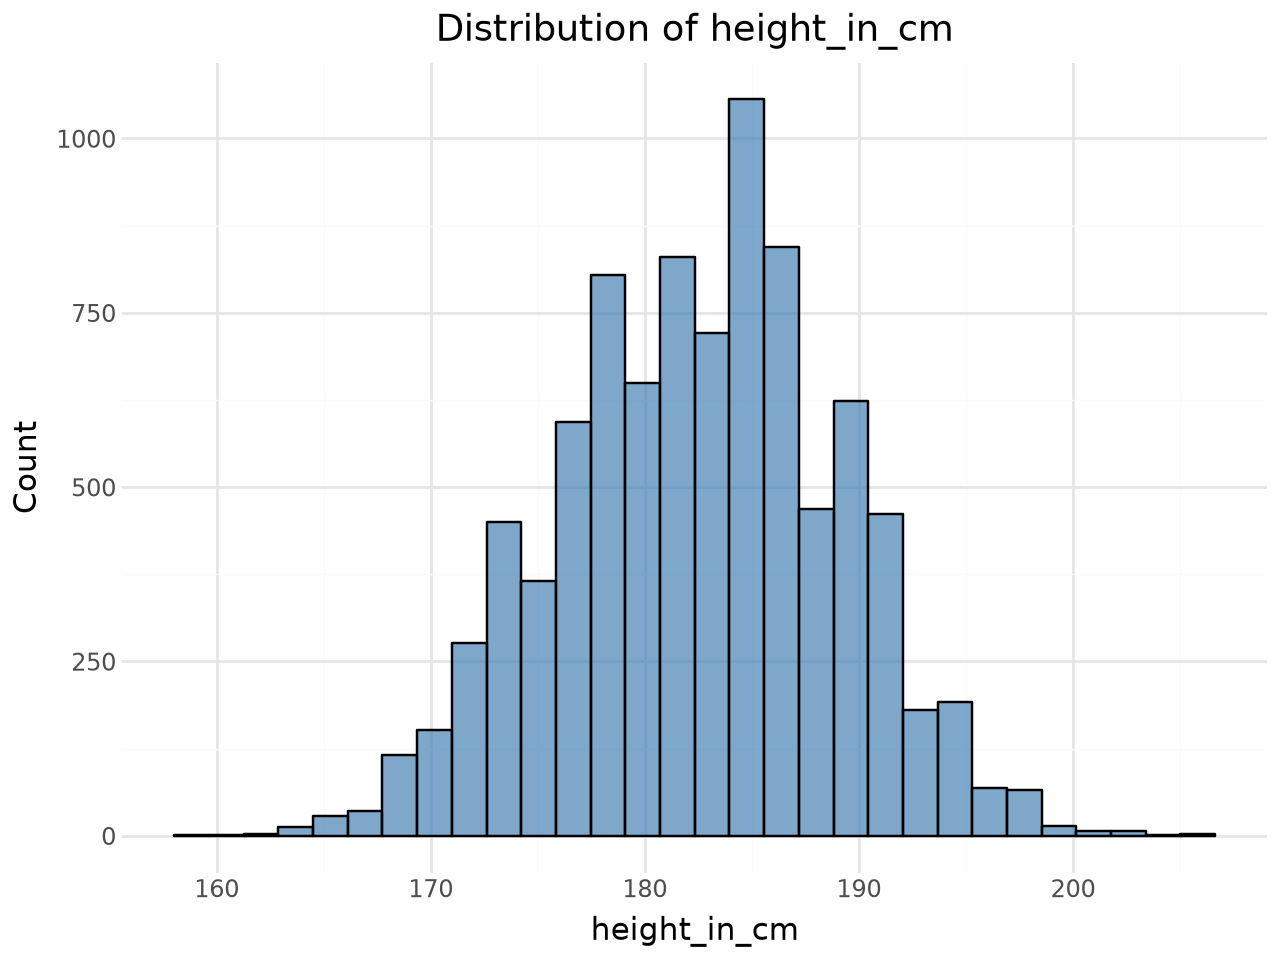


--- Distribution of market_value_in_eur ---


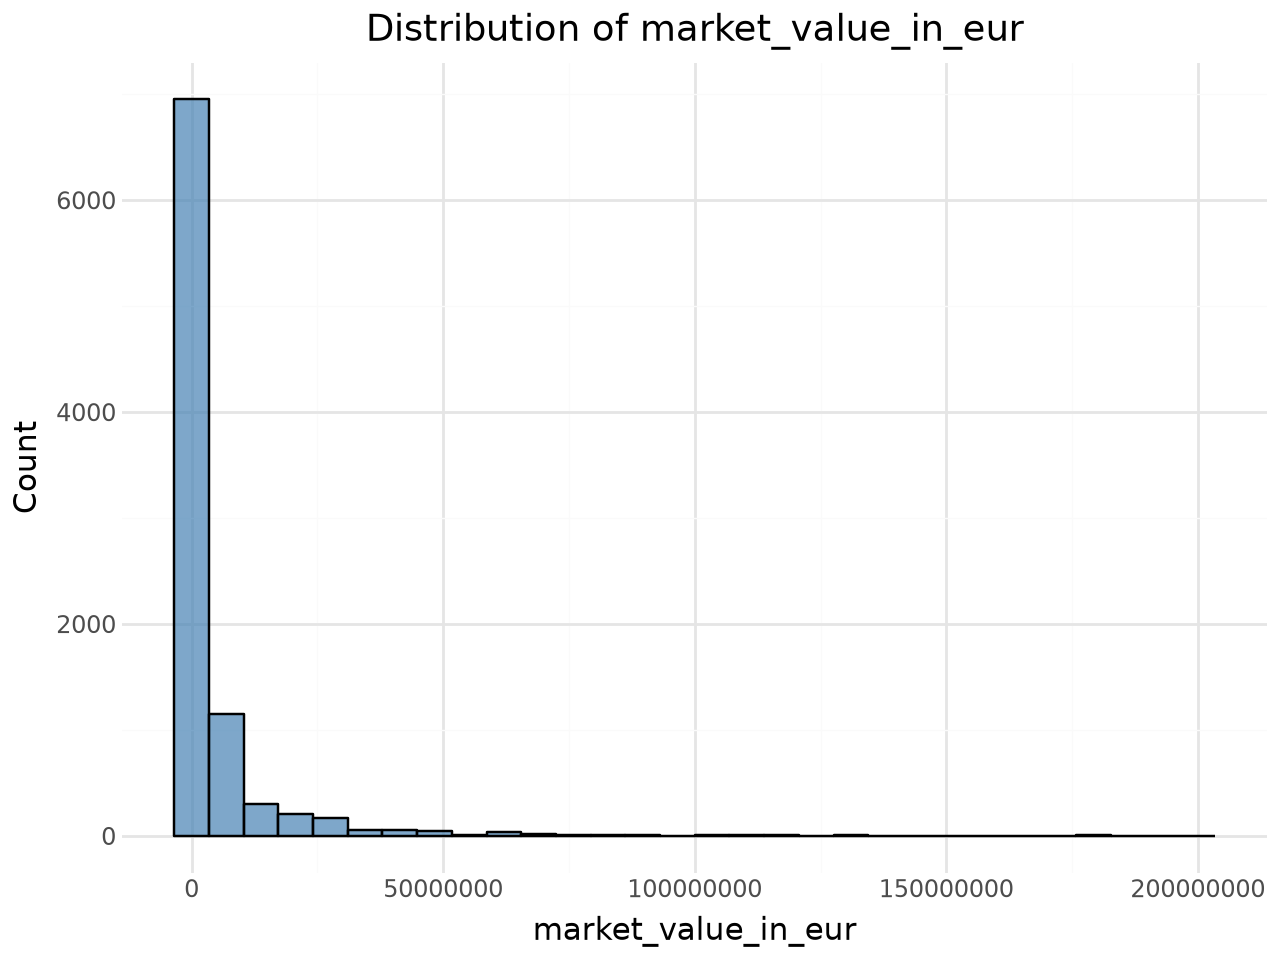


--- Distribution of goals ---


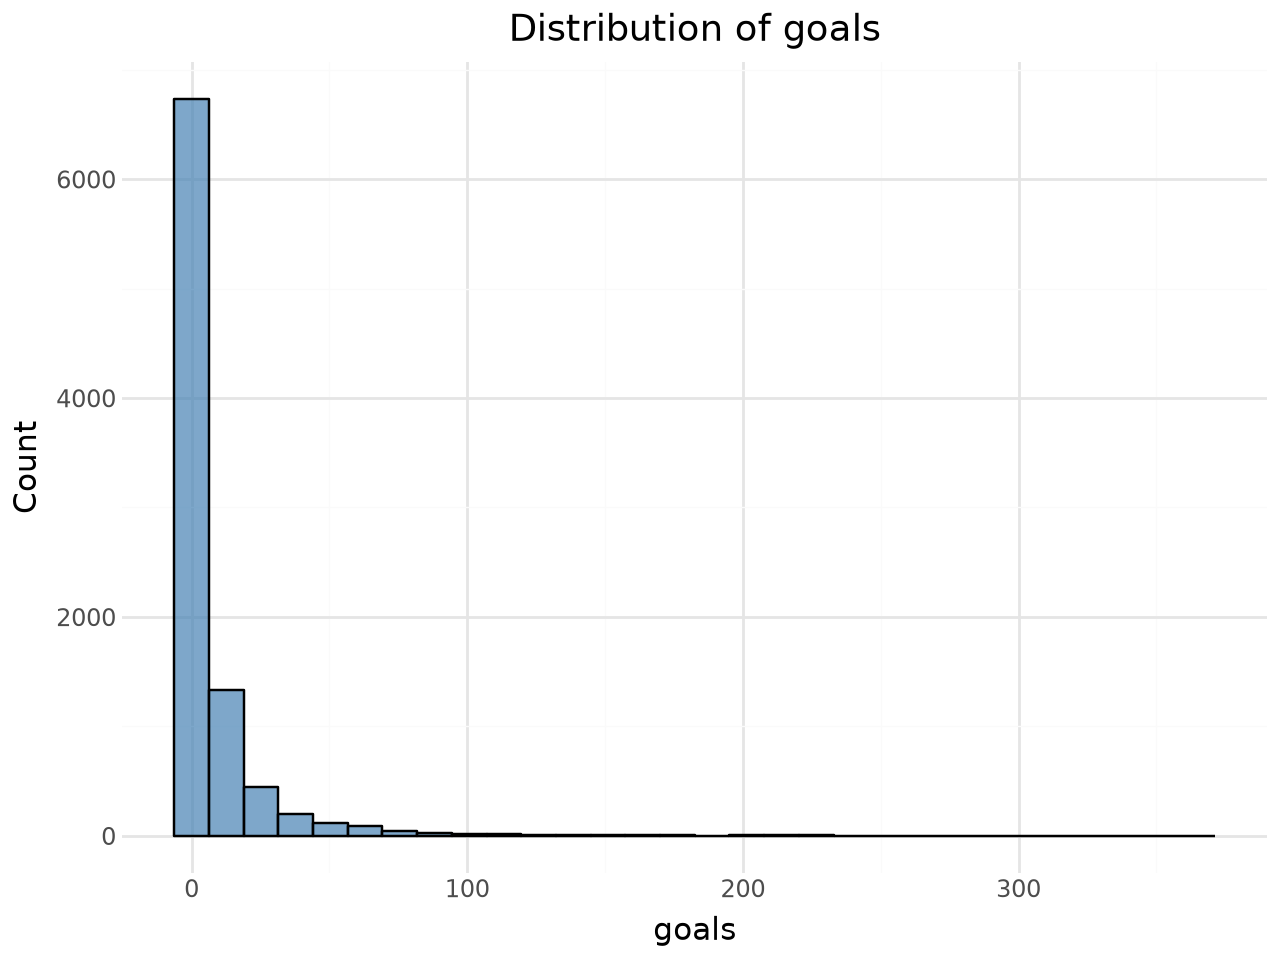


--- Distribution of assists ---


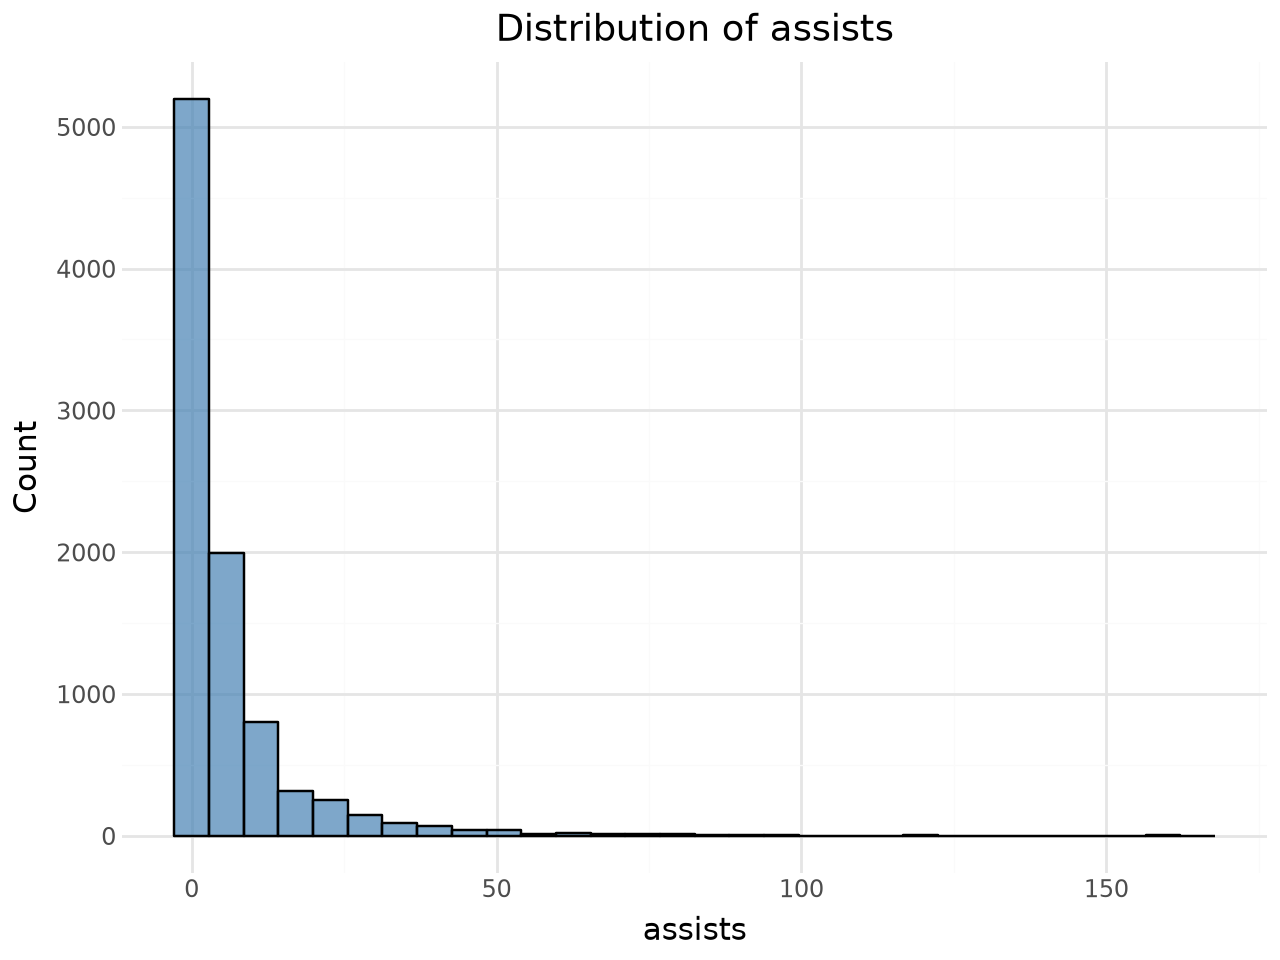


--- Distribution of minutes_played ---


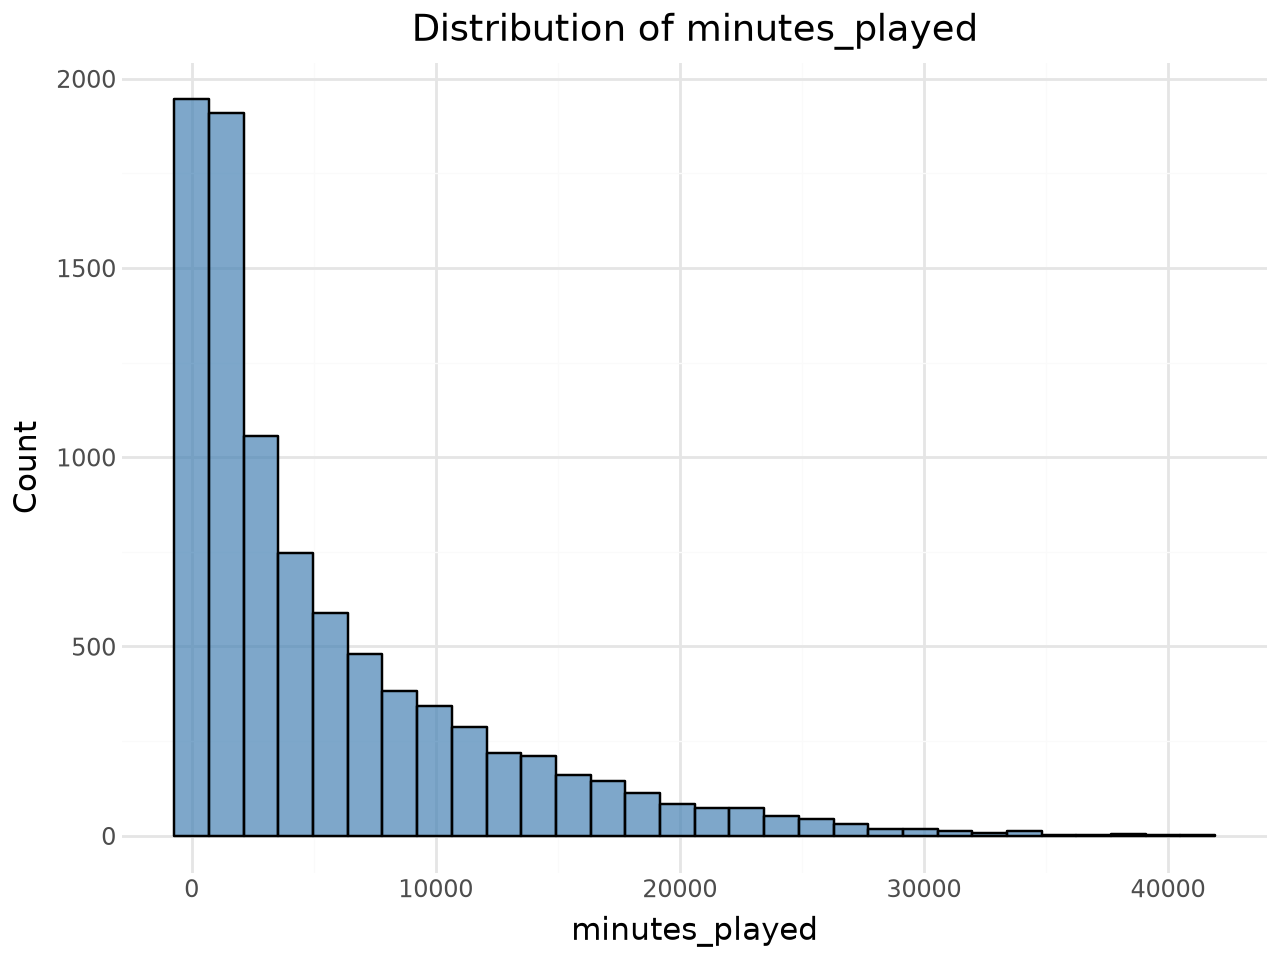


--- Distribution of yellow_cards ---


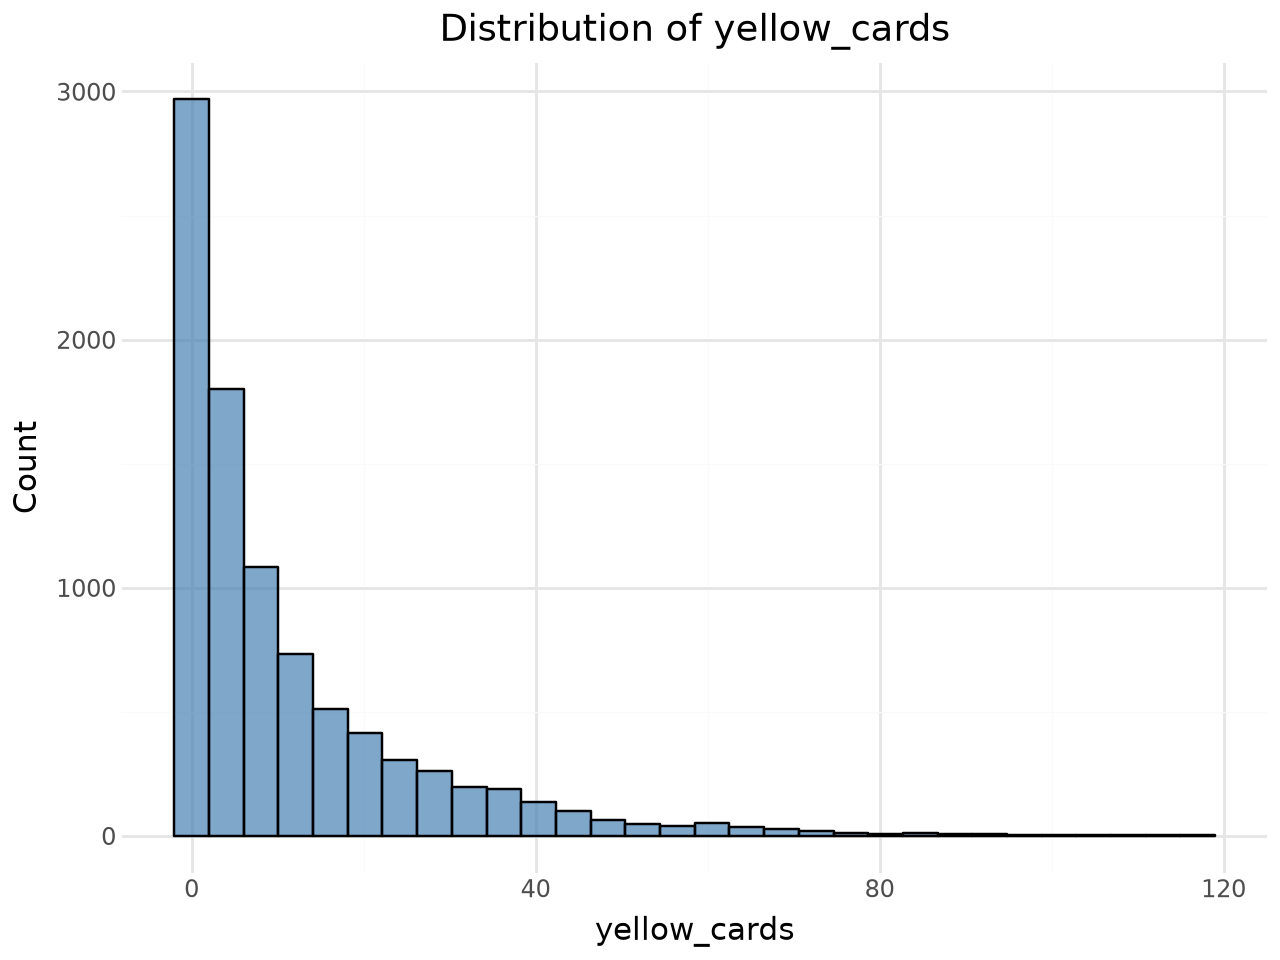


--- Distribution of red_cards ---


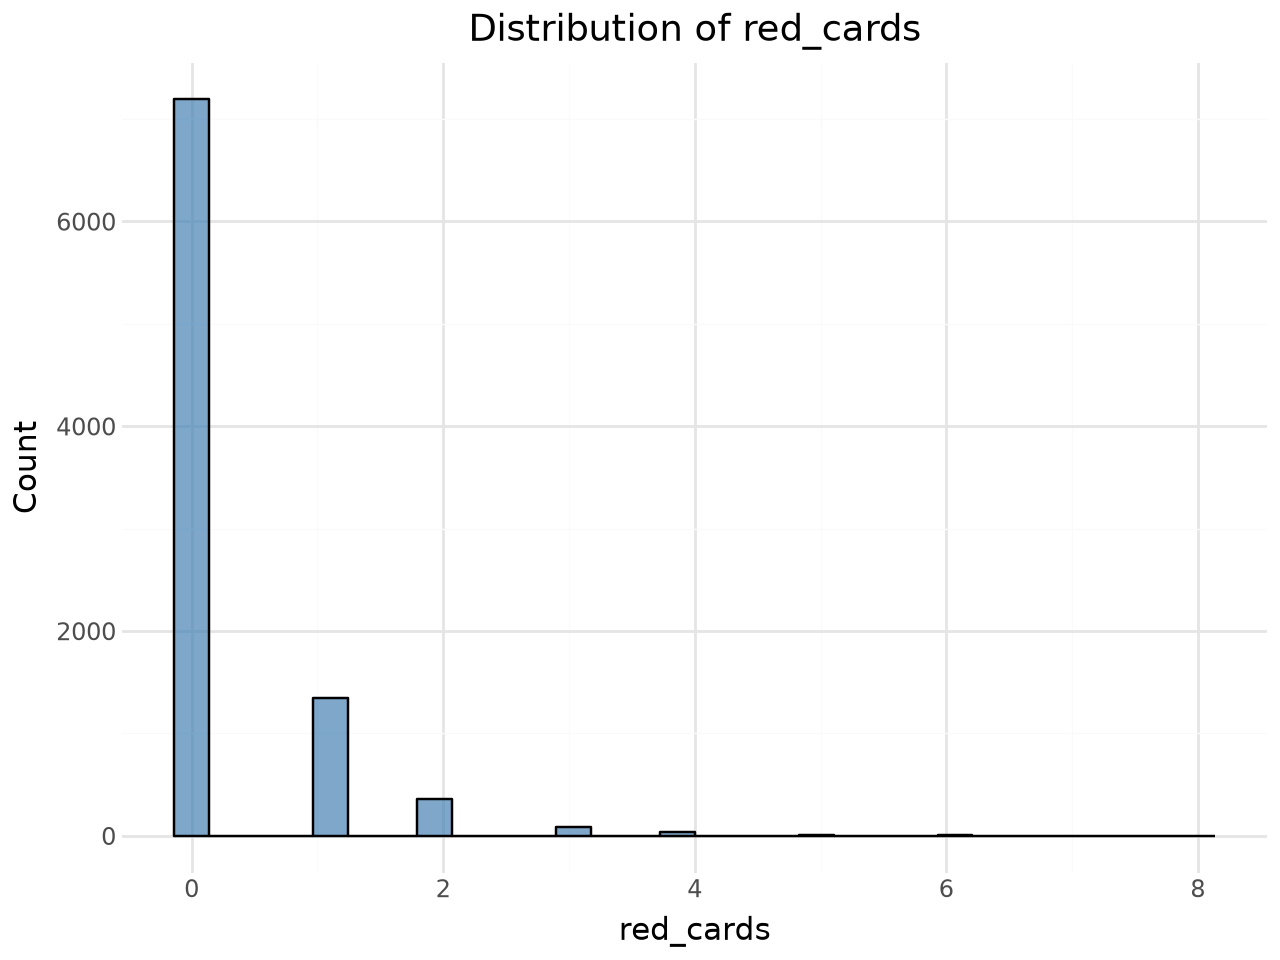

In [ ]:
from IPython.display import display

for col in num_cols:
    print(f"\n--- Distribution of {col} ---")
    
    p = (
        ggplot(df, aes(x=col))
        + geom_histogram(bins=30, fill='steelblue', color='black', alpha=0.7)
        + labs(title=f"Distribution of {col}", x=col, y="Count")
        + theme_minimal()
    )
    
    display(p)

In [28]:

def detect_outliers(df, col):
    print(f"--- Outliers Detection for '{col}' ---")
    
    # 1. IQR Method (Tukey's Fences)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound_iqr = Q1 - 1.5 * IQR
    upper_bound_iqr = Q3 + 1.5 * IQR
    outliers_iqr = df[(df[col] < lower_bound_iqr) | (df[col] > upper_bound_iqr)]
    print(f"1. IQR Method: {len(outliers_iqr)} outliers detected.")
    
    # 2. Z-Score Method
    mean = df[col].mean()
    std = df[col].std()
    z_scores = (df[col] - mean) / std
    outliers_z = df[(z_scores > 3) | (z_scores < -3)]
    print(f"2. Z-Score Method: {len(outliers_z)} outliers detected.")
    
    # 3. Robust Z-Score Method (using MAD)
    median = df[col].median()
    mad = (df[col] - median).abs().median()
    # Using 1.4826 to approximate standard deviation for normal distribution
    if mad != 0:
        robust_z_scores = (df[col] - median) / (mad * 1.4826)
        outliers_robust = df[(robust_z_scores > 3) | (robust_z_scores < -3)]
        print(f"3. Robust Z-Score Method: {len(outliers_robust)} outliers detected.\\n")
    else:
        print("3. Robust Z-Score Method: Cannot compute (MAD is 0).\\n")

# Testing on a symmetrical variable and a highly skewed variable
detect_outliers(df, 'height_in_cm')
detect_outliers(df, 'market_value_in_eur')

--- Outliers Detection for 'height_in_cm' ---
1. IQR Method: 41 outliers detected.
2. Z-Score Method: 12 outliers detected.
3. Robust Z-Score Method: 4 outliers detected.\n
--- Outliers Detection for 'market_value_in_eur' ---
1. IQR Method: 1496 outliers detected.
2. Z-Score Method: 199 outliers detected.
3. Robust Z-Score Method: 2135 outliers detected.\n


**Outliers Detection Analysis:**
We applied three different outlier detection methods to two variables: one with a symmetrical distribution (`height_in_cm`) and one with a heavy positive skew (`market_value_in_eur`). 
For symmetrical distributions, the Z-score method works well. However, for heavily skewed variables like market value, the Z-score method fails to capture many outliers because the mean and standard deviation are artificially inflated by the extreme values (the superstars). In such cases, the IQR and Robust Z-score methods, which rely on the Median and MAD, perform significantly better as they are resistant to these extreme values.

### 5.1 Univariate Analysis: Numerical Variables

**Methodology:**
In this section, we analyze the numerical features of the dataset: `height_in_cm`, `market_value_in_eur`, `goals`, `assists`, `minutes_played`, `yellow_cards`, and `red_cards`. 
For each variable, we calculate the central tendency (Mean, Median) and dispersion metrics (Standard Deviation, MAD, Min, Max, Q1, Q3, and IQR). Additionally, we compute the skewness to understand the distribution's shape and detect outliers using three different methods: Z-score, Tukey's Fences (IQR method), and Robust Z-score (MAD method). Visualizations are created using `plotnine` to plot histograms.

**Conclusions & Discussion:**
* **Distribution Shapes & Skewness:** Variables such as `market_value_in_eur`, `goals`, and `assists` exhibit a strong right positive skew (long right tail). This indicates that while the majority of players have lower market values and fewer goals, a small number of elite players have exceptionally high values.
* **Central Tendency Representativeness:** For heavily skewed variables (like market value), the *Mean* is pulled upwards by extreme outliers (superstars) and does not accurately represent the typical player. Therefore, the *Median* and *MAD* are much better indicators of central tendency and dispersion for these features. Conversely, physical attributes like `height_in_cm` follow a fairly normal (symmetrical) distribution, making the Mean and Standard Deviation perfectly suitable representations.

--- position ---
Top Frequencies (%):
position
Defender      34.341420
Midfield      28.824637
Attack        28.436911
Goalkeeper     8.330564
Missing        0.066467
Name: proportion, dtype: float64
Mode: 'Defender', which represents 34.34% of the data
It takes 3 unique values to describe approximately 80% of the data.


--- foot ---
Top Frequencies (%):
foot
right    71.740335
left     24.914146
both      3.345519
Name: proportion, dtype: float64
Mode: 'right', which represents 71.74% of the data
It takes 2 unique values to describe approximately 80% of the data.


--- country_of_citizenship ---
Top Frequencies (%):
country_of_citizenship
Spain      13.548244
France     10.191647
Italy       8.585355
Germany     7.743436
England     6.181456
Name: proportion, dtype: float64
Mode: 'Spain', which represents 13.55% of the data
It takes 29 unique values to describe approximately 80% of the data.



--- Frequencies of position ---


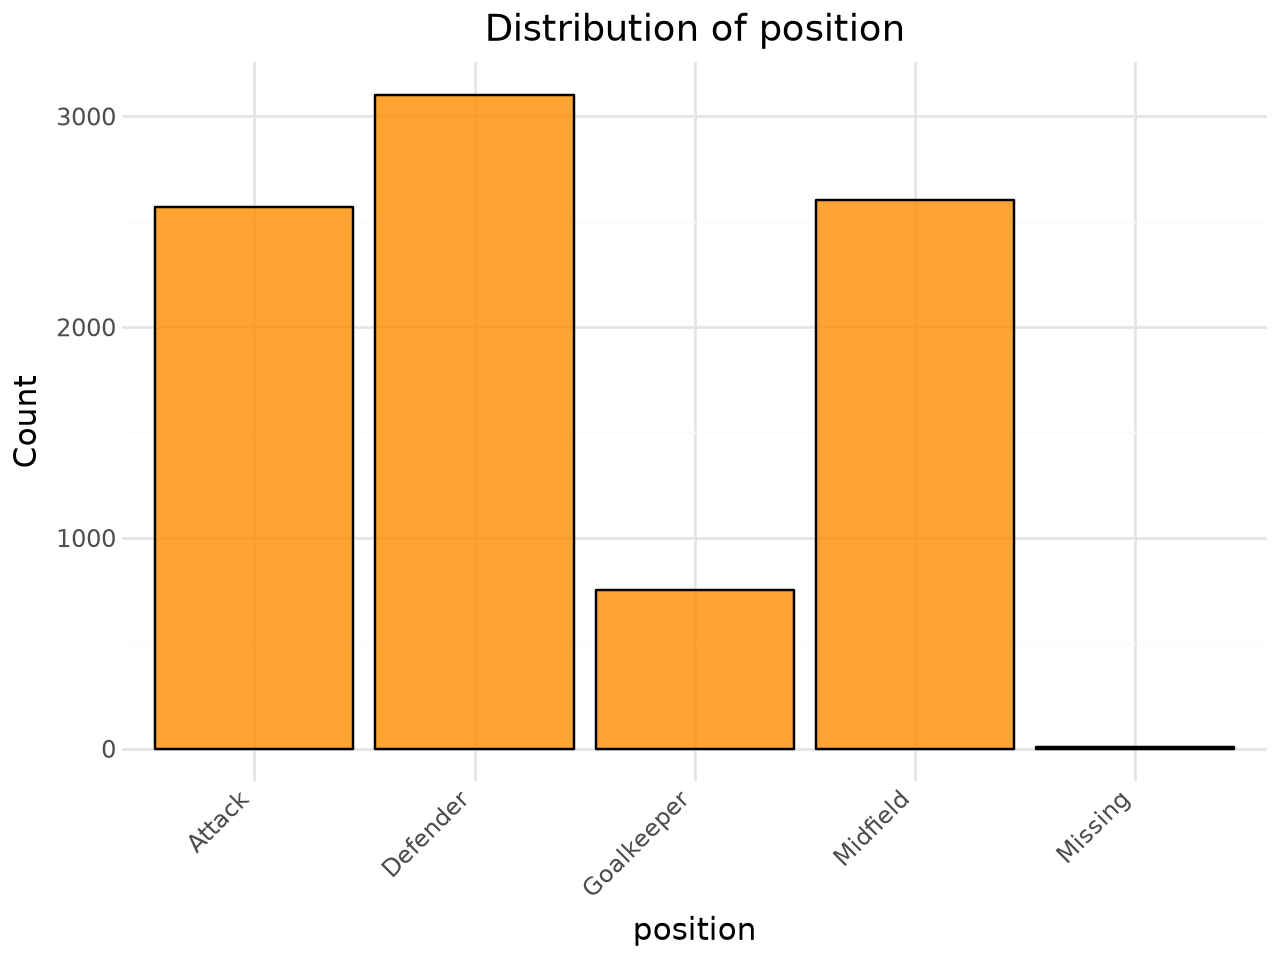


--- Frequencies of foot ---


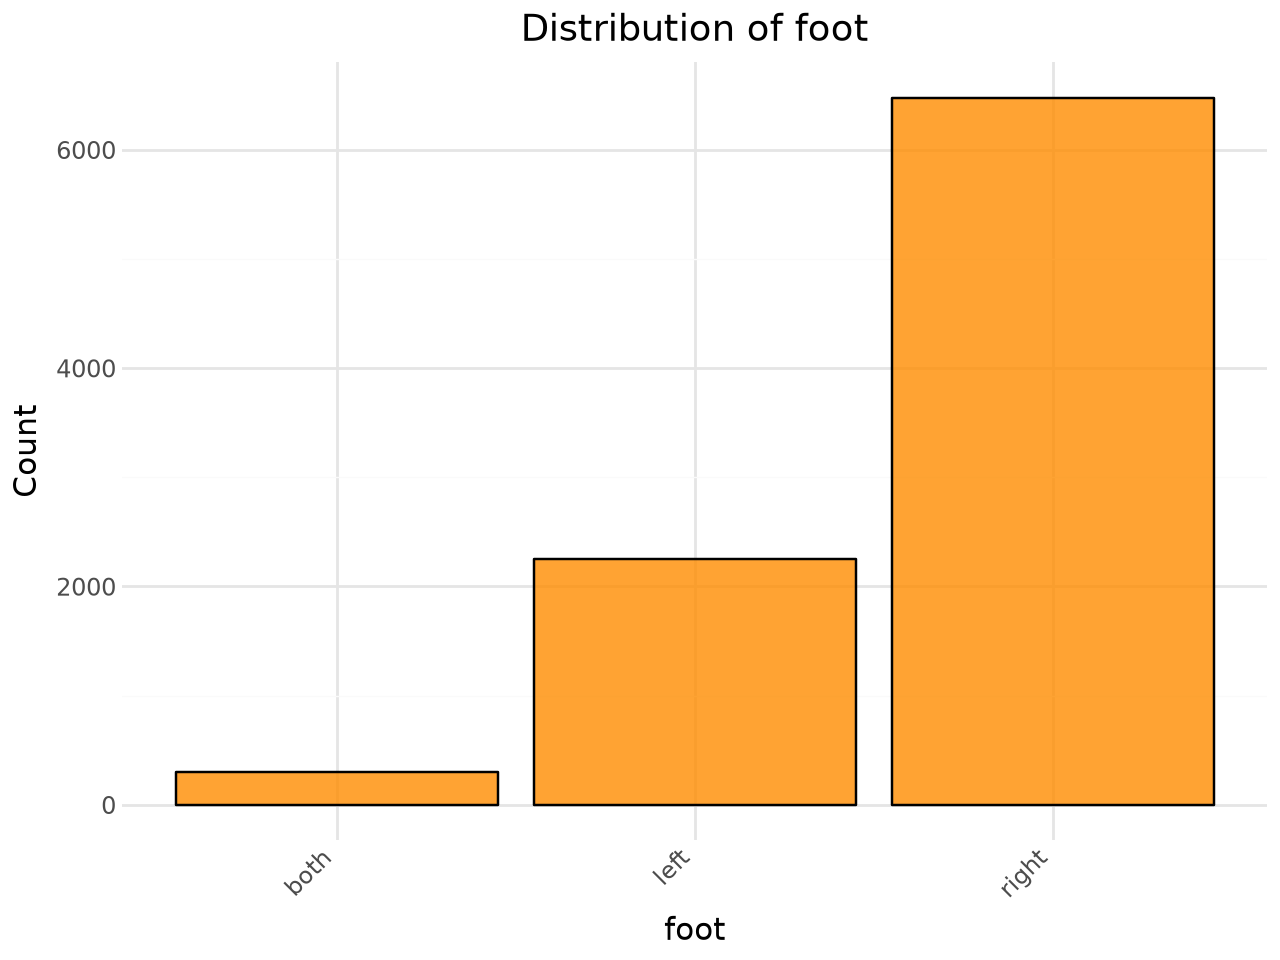


--- Frequencies of country_of_citizenship ---


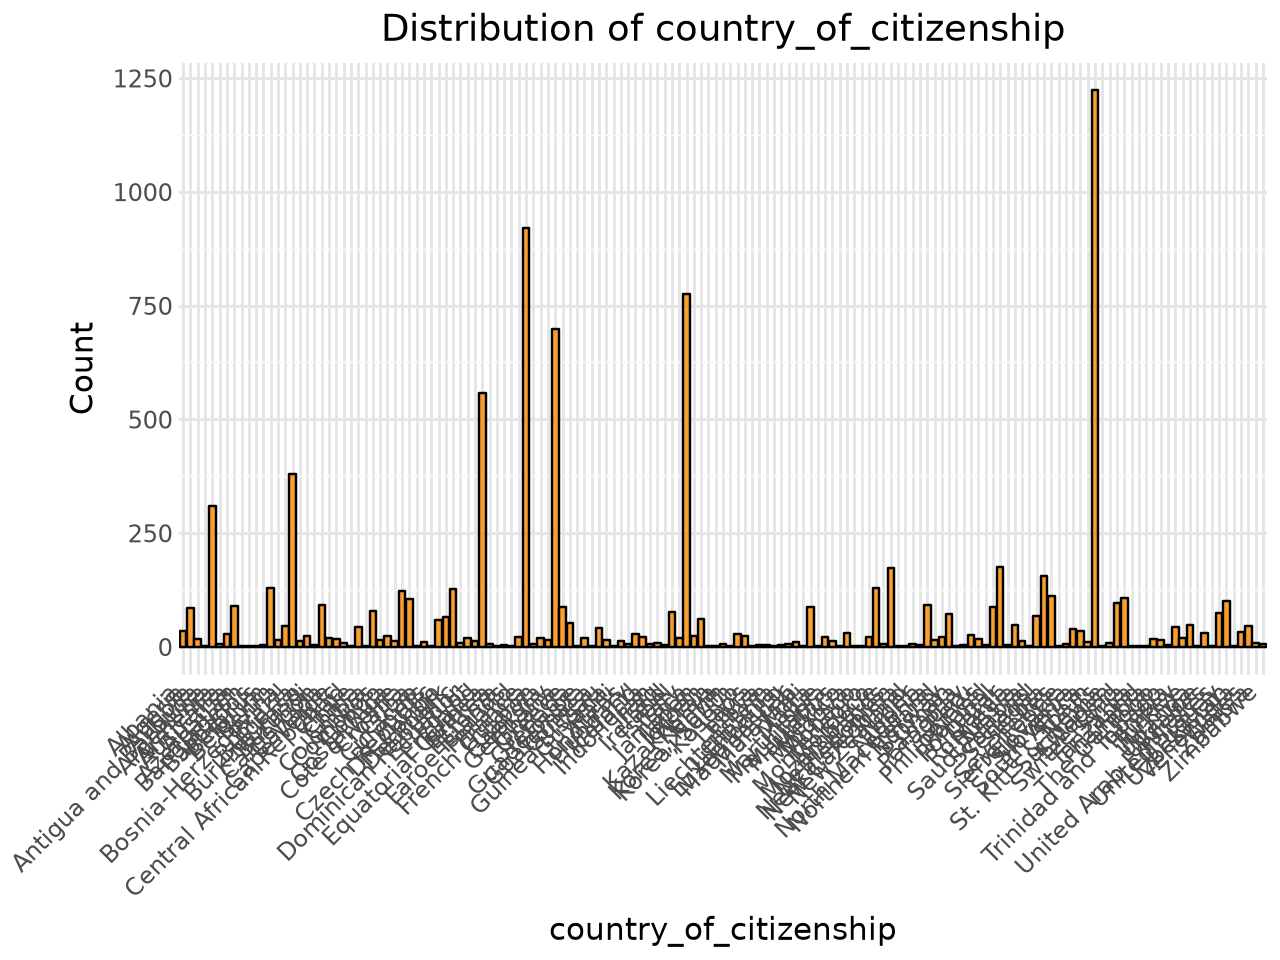

In [ ]:
# Define the categorical columns to analyze
cat_cols = ['position', 'foot', 'country_of_citizenship']

for col in cat_cols:
    print(f"--- {col} ---")
    
    # Calculate relative frequencies (percentages) for each category
    freq = df[col].value_counts(normalize=True) * 100
    print("Top Frequencies (%):")
    # Display the top 5 most frequent categories (Top K)
    print(freq.head(5)) 
    
    # Identify the Mode and its representation percentage
    mode_val = freq.index[0]
    mode_pct = freq.iloc[0]
    print(f"Mode: '{mode_val}', which represents {mode_pct:.2f}% of the data")
    
    # Calculate how many unique categories are needed to cover P% of the data
    cumulative_pct = freq.cumsum()
    p_threshold = 80 # Setting the threshold at 80%
    values_needed = (cumulative_pct <= p_threshold).sum() + 1
    print(f"It takes {values_needed} unique values to describe approximately {p_threshold}% of the data.")
    print("\n")

# Visualize the categorical frequencies using plotnine (Example: Player Position)
p_position = (
    ggplot(df, aes(x='position'))
    + geom_bar(fill='orange', color='black')
    + labs(title="Player Positions Distribution", x="Position", y="Count")
    + theme_minimal()
    # Rotating x-axis text for better readability if category names are long
    + theme(axis_text_x=element_text(rotation=45, hjust=1)) 
)
from IPython.display import display

cat_cols = ['position', 'foot', 'country_of_citizenship']

for col in cat_cols:
    print(f"\n--- Frequencies of {col} ---")
    
    p = (
        ggplot(df, aes(x=col))
        + geom_bar(fill='darkorange', color='black', alpha=0.8)
        + labs(title=f"Distribution of {col}", x=col, y="Count")
        + theme_minimal()
        + theme(axis_text_x=element_text(rotation=45, hjust=1)) 
    )
    
    # הצגת הגרף
    display(p)

In [29]:

country_counts = df['country_of_citizenship'].value_counts(normalize=True) * 100
rare_countries = country_counts[country_counts < 1.0].index

print(f"Number of rare countries (less than 1% representation): {len(rare_countries)}")
print(f"Total percentage of data represented by these rare countries combined: {country_counts[rare_countries].sum():.2f}%\\n")

# Unifying rare categories into a single 'Other' category
df['country_grouped'] = df['country_of_citizenship'].apply(lambda x: x if x not in rare_countries else 'Other')

print("New Frequencies after unification:")
print(df['country_grouped'].value_counts(normalize=True).head() * 100)

Number of rare countries (less than 1% representation): 135
Total percentage of data represented by these rare countries combined: 28.77%\n
New Frequencies after unification:
country_grouped
Other      28.768033
Spain      13.430144
France     10.573273
Italy       8.940774
Germany     7.991648
Name: proportion, dtype: float64


**Rare Categories Analysis:**
As analyzed in the `country_of_citizenship` column, there is a very long tail of rare categories (countries that appear very few times, representing less than 1% of the data each). 
*Do they hold information?* In a specific scouting context, a player from a rare country might be an interesting finding. However, for statistical modeling and general EDA, they introduce high cardinality noise and make visualizations cluttered.
*Can they be unified?* Yes. As demonstrated above, grouping these rare values into a single "Other" category (or alternatively, grouping them by continent) dramatically reduces cardinality while retaining the overarching demographic structure, making it much more suitable for machine learning models.

In [12]:
# Analyze a categorical feature, e.g., 'position'
target_col = 'position'

# 1. Mode and its frequency percentage
mode_val = df[target_col].mode()[0]
mode_count = df[target_col].value_counts().iloc[0]
mode_pct = (mode_count / len(df)) * 100
print(f"The Mode is '{mode_val}' appearing {mode_count} times ({mode_pct:.2f}% of the data).")

# 2. Top K most frequent values (let's say K=3) and their cumulative percentage
K = 3
top_k_counts = df[target_col].value_counts().head(K)
top_k_pct = top_k_counts.sum() / len(df) * 100
print(f"\nTop {K} categories:\n{top_k_counts}")
print(f"They cover {top_k_pct:.2f}% of the data.")

# 3. Minimum number of values needed to describe P percent of the data (e.g., P = 80%)
P = 80
cumulative_pct = df[target_col].value_counts(normalize=True).cumsum() * 100
min_values_for_p = (cumulative_pct <= P).sum() + 1
print(f"\nMinimum number of categories to cover {P}% of the data: {min_values_for_p}")
print("These categories are:\n", cumulative_pct.head(min_values_for_p))

The Mode is 'Defender' appearing 3100 times (34.34% of the data).

Top 3 categories:
position
Defender    3100
Midfield    2602
Attack      2567
Name: count, dtype: int64
They cover 91.60% of the data.

Minimum number of categories to cover 80% of the data: 3
These categories are:
 position
Defender    34.341420
Midfield    63.166057
Attack      91.602969
Name: proportion, dtype: float64


### 5.2 Univariate Analysis: Categorical Variables

**Methodology:**
In this section, we analyze the categorical features: `position`, `foot`, and `country_of_citizenship`. 
We extract the frequency of each category (as a percentage of the total data), identify the mode (the most frequent category), and calculate how much of the dataset it represents. We also determine the minimum number of unique values required to represent a significant portion (e.g., 80%) of the dataset. Bar charts are plotted using `plotnine` for visual representation.

**Conclusions & Discussion:**
* **Dominant Categories & Mode:** We can easily identify the most common positions and preferred foot among players in the top 5 leagues. 
* **High Cardinality & Rare Categories:** The `country_of_citizenship` variable has high cardinality. While top footballing nations (like France, Spain, Brazil) make up a large percentage of the dataset, there is a "long tail" of countries represented by only one or two players.
* **Feature Engineering Recommendation:** These rare categories carry little statistical weight and might introduce noise or overfitting into future machine learning models. It is highly recommended to group these infrequent countries into a single "Other" category to reduce dimensionality while preserving data integrity.

### Univariate Analysis Summary & Discussion
**Discussion: Do the central metrics represent the data well?**
The answer depends entirely on the variable's distribution:
1. **For skewed variables** (e.g., `market_value_in_eur`, `goals`, `assists`): The 'Mean' is heavily influenced by the right tail of extreme values (top-tier players scoring many goals or holding massive market values). Because of this, the Mean is artificially pulled upwards and **does not** represent the "typical" player well. For these variables, the **Median** is a far superior and accurate representation of the central tendency.
2. **For symmetrically distributed variables** (e.g., `height_in_cm`): The Mean and Median are almost identical (Mean: 182.47, Median: 183). In this case, the central metrics represent the data exceptionally well, and the Mean is a reliable indicator of a typical player's height.

In [36]:
%pip install seaborn scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 9.5 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 19.6 MB/s  0:00:00

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwh


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


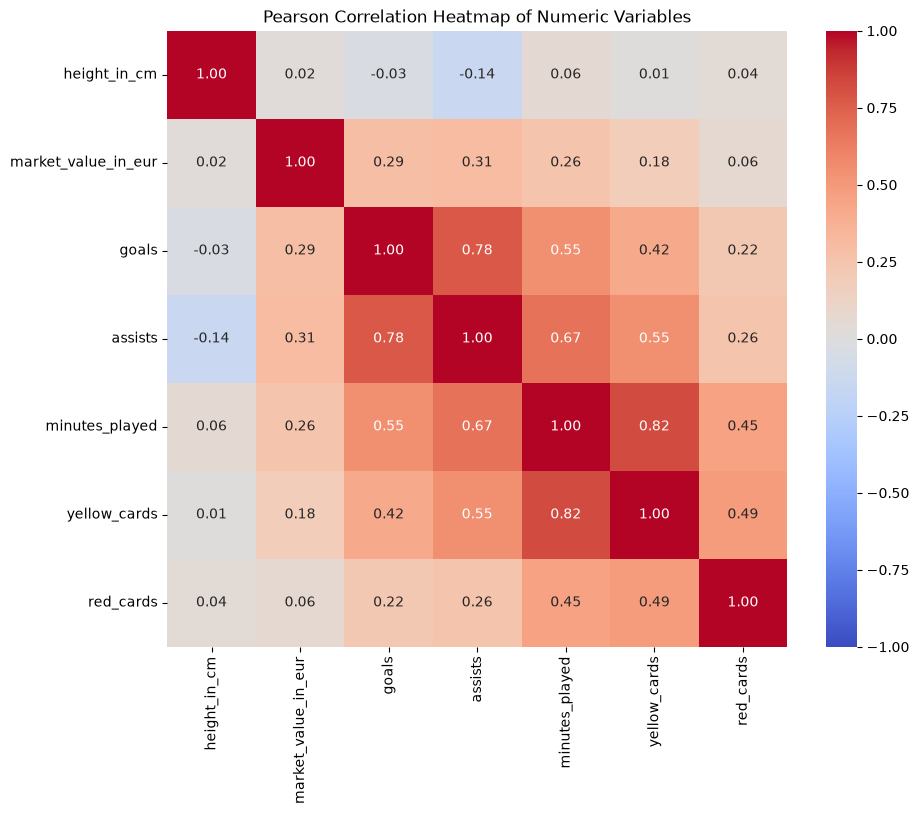

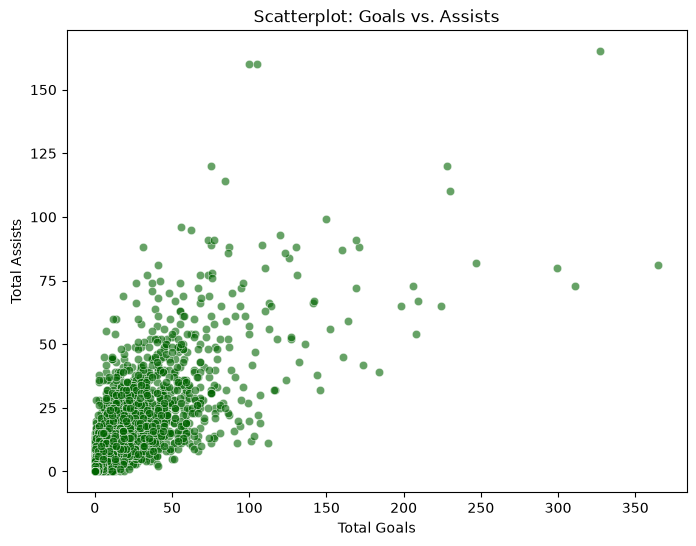

In [38]:

import seaborn as sns
import matplotlib.pyplot as plt

# --- 6.1 Numeric-Numeric Correlations ---

# Select only numeric columns
numeric_cols = ['height_in_cm', 'market_value_in_eur', 'goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards']
df_num = df[numeric_cols]

# Calculate correlations using the 3 methods
corr_pearson = df_num.corr(method='pearson')
corr_spearman = df_num.corr(method='spearman')
corr_kendall = df_num.corr(method='kendall')

# Plotting the Pearson Correlation Matrix (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Pearson Correlation Heatmap of Numeric Variables")
plt.show()

# Plotting a Scatterplot to visualize a specific strong relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='goals', y='assists', alpha=0.6, color='darkgreen')
plt.title("Scatterplot: Goals vs. Assists")
plt.xlabel("Total Goals")
plt.ylabel("Total Assists")
plt.show()

### 6.1 Numeric-Numeric Correlations

**Differences between correlation methods:**
1. **Pearson:** Measures the linear relationship between two continuous variables. It assumes the variables are normally distributed.
2. **Spearman:** A non-parametric measure (rank correlation) that assesses monotonic relationships (whether linear or not). It is highly robust to outliers (like the extreme market values in our dataset).
3. **Kendall:** Similar to Spearman, it measures ordinal association based on the concordant and discordant pairs of ranks. It is often preferred for smaller datasets or data with many tied ranks.

**Insights from the Correlation Matrix & Scatterplot:**
* **Strong Positive Correlations:** There is a high correlation between `goals` and `assists`, as well as between `minutes_played` and both offensive metrics and `yellow_cards`. This makes sense: players who play more have more opportunities to score, assist, and commit fouls.
* **Market Value Influencers:** The `market_value_in_eur` shows a moderate positive correlation with `goals` and `assists`, confirming that offensive output significantly impacts a player's valuation. 
* **Height Independence:** `height_in_cm` has a near-zero correlation with almost all other metrics, indicating that physical height does not universally dictate a player's general performance metrics or market value across all positions.

In [39]:
# --- 6.2 Categorical-Categorical & Binning ---

# 1. Frequency Table (Crosstab): Position vs Preferred Foot
freq_table = pd.crosstab(df['position'], df['foot'])
print("--- Frequency Table: Position vs Preferred Foot ---")
display(freq_table)

# 2. Binning: Converting a numerical variable ('market_value_in_eur') into categories
# We divide the market value into 3 categories: Low, Medium, High using quantiles
df['market_value_tier'] = pd.qcut(df['market_value_in_eur'], q=3, labels=['Low Value', 'Medium Value', 'High Value'])

# Finding the relationship between Position (Categorical) and Market Value Tier (Binned Numerical)
binned_crosstab = pd.crosstab(df['position'], df['market_value_tier'], normalize='index') * 100
print("\\n--- Row Percentages: Position vs Market Value Tiers ---")
display(binned_crosstab.round(2))

# 3. Cramer's V (Optional) to quantify the association between Position and Foot
import scipy.stats as ss

def cramers_v(confusion_matrix):
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

v_score = cramers_v(freq_table.values)
print(f"\\nCramer's V score between Position and Foot: {v_score:.3f}")

--- Frequency Table: Position vs Preferred Foot ---


foot,both,left,right
position,,,
Attack,144,682,2295
Defender,76,1173,2085
Goalkeeper,20,100,658
Midfield,133,664,2281
Missing,2,1,6


\n--- Row Percentages: Position vs Market Value Tiers ---


market_value_tier,Low Value,Medium Value,High Value
position,,,
Attack,32.72,33.72,33.56
Defender,33.47,34.05,32.48
Goalkeeper,46.12,31.20,22.68
Midfield,33.24,34.21,32.54
Missing,88.89,11.11,0.00


\nCramer's V score between Position and Foot: 0.121


### 6.2 Categorical Relationships & Binning

**Methodology & Insights:**
* **Frequency Tables & Cramer's V:** We generated a crosstab between `position` and `foot`. The calculated Cramer's V score helps us understand the strength of this association. For instance, Goalkeepers and Defenders might show specific foot dominances compared to Midfielders.
* **Binning Numerical to Categorical:** We took the continuous `market_value_in_eur` variable and binned it into three distinct tiers ('Low', 'Medium', 'High') using quantile-based discretization (`pd.qcut`). 
* **Relationship Insights:** By cross-tabulating `position` with these new `market_value_tier` bins (normalized by rows to show percentages), we can observe economic inequalities on the pitch. For example, Attackers traditionally have a higher percentage falling into the 'High Value' tier compared to Defenders or Goalkeepers, reflecting the football market's premium on goal-scorers.

C:\Users\ayele\AppData\Local\Temp\ipykernel_13532\2777312054.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\ayele\AppData\Local\Temp\ipykernel_13532\2777312054.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\ayele\AppData\Local\Temp\ipykernel_13532\2777312054.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



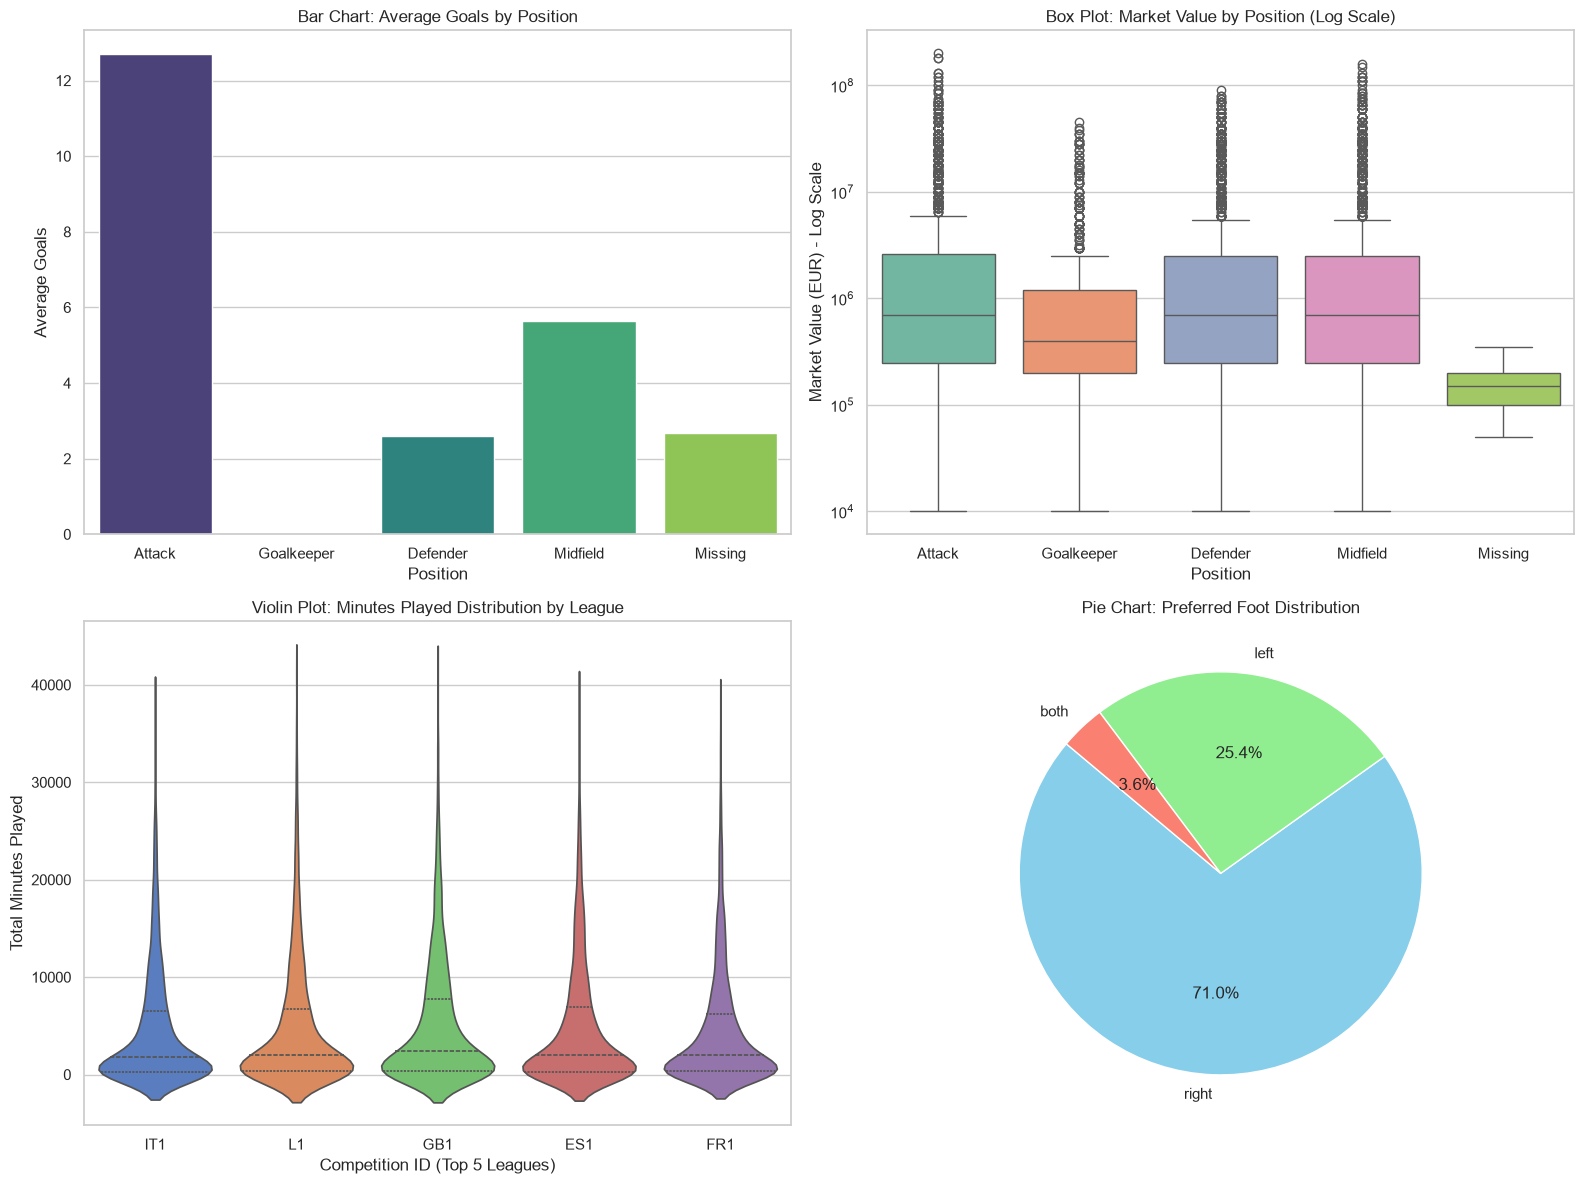

\n--- Pairplot of Key Metrics ---


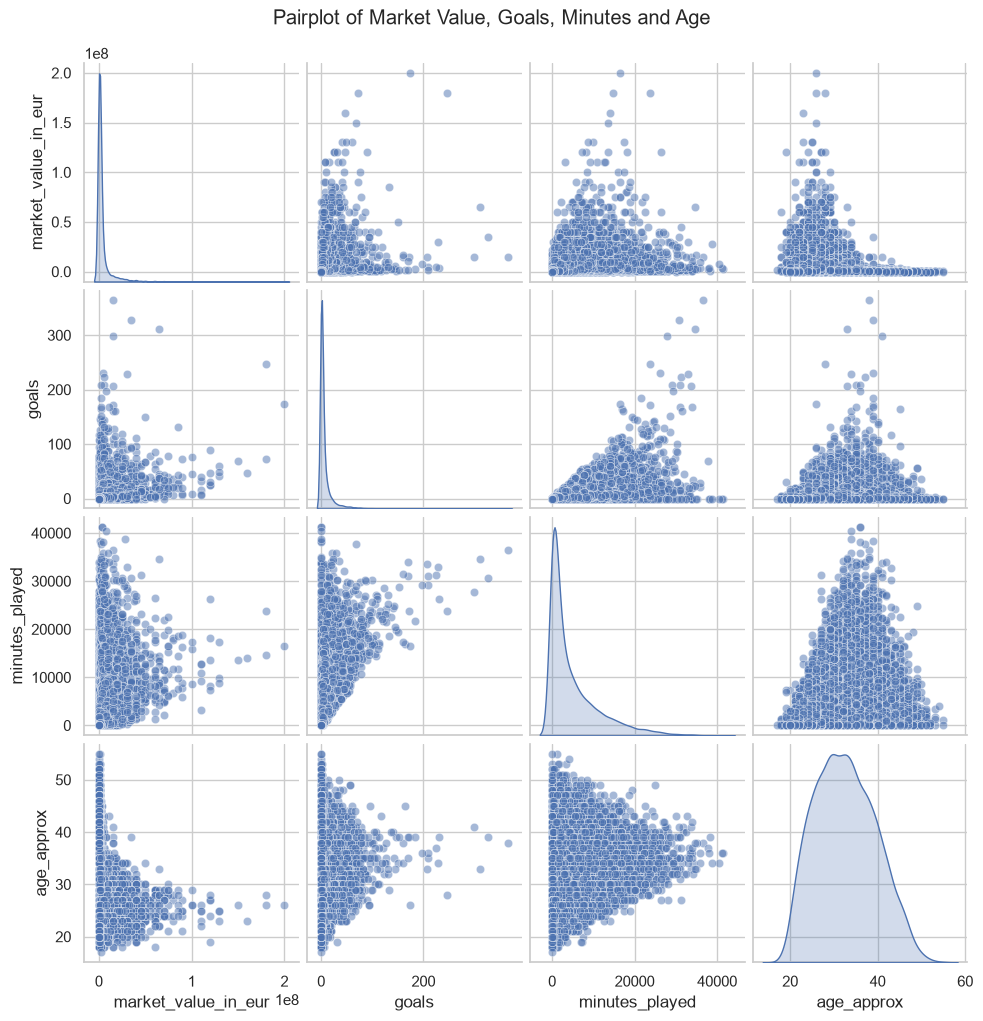

In [40]:
# --- 6.3 Required Visualizations ---

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 12))

# 1. Bar Chart: Average Goals by Position
plt.subplot(2, 2, 1)
sns.barplot(data=df, x='position', y='goals', estimator='mean', errorbar=None, palette='viridis')
plt.title("Bar Chart: Average Goals by Position")
plt.xlabel("Position")
plt.ylabel("Average Goals")

# 2. Box Plot: Market Value by Position (Log Scale due to outliers)
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='position', y='market_value_in_eur', palette='Set2')
plt.yscale('log')
plt.title("Box Plot: Market Value by Position (Log Scale)")
plt.xlabel("Position")
plt.ylabel("Market Value (EUR) - Log Scale")

# 3. Violin Plot: Minutes Played by Competition
plt.subplot(2, 2, 3)
sns.violinplot(data=df, x='competition_id', y='minutes_played', palette='muted', inner="quartile")
plt.title("Violin Plot: Minutes Played Distribution by League")
plt.xlabel("Competition ID (Top 5 Leagues)")
plt.ylabel("Total Minutes Played")

# 4. Pie Chart: Foot Dominance
plt.subplot(2, 2, 4)
foot_counts = df['foot'].value_counts()
plt.pie(foot_counts, labels=foot_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen', 'salmon'])
plt.title("Pie Chart: Preferred Foot Distribution")

plt.tight_layout()
plt.show()

# 5. Pairplot: Exploring multiple numeric relationships simultaneously
# We use a subset to keep the plot readable and efficient
pairplot_cols = ['market_value_in_eur', 'goals', 'minutes_played', 'age_binned']
# Creating age from date of birth (simple approximation for visualization purposes)
df['birth_year'] = pd.to_datetime(df['date_of_birth']).dt.year
df['age_approx'] = 2026 - df['birth_year'] 

print("\\n--- Pairplot of Key Metrics ---")
sns.pairplot(df[['market_value_in_eur', 'goals', 'minutes_played', 'age_approx']].dropna(), diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairplot of Market Value, Goals, Minutes and Age", y=1.02)
plt.show()

### 6.3 Visualizations & Storytelling

* **Bar Chart (Average Goals by Position):** Clearly demonstrates the tactical reality of the sport—Attackers heavily dominate goal-scoring, followed by Midfielders.
* **Box Plot (Market Value by Position):** By applying a logarithmic scale (due to the extreme right skew of superstar valuations), we can see the median and IQR of market values. Attackers and Midfielders tend to have a higher ceiling and median value compared to Goalkeepers.
* **Violin Plot (Minutes Played by League):** Shows the distribution density of playing time across the top 5 European leagues. The distributions appear fairly consistent across the leagues, showing a wide base of players with lower minutes and a steady tail of regular starters.
* **Pie Chart (Preferred Foot):** Visually confirms the extreme dominance of right-footed players (~72%) compared to left-footed and two-footed players.
* **Pairplot:** Provides a rapid, multi-dimensional view of continuous features. It highlights how variables like Age interact with Market Value (value peaks around mid-20s and drops as players get older), while Goals and Minutes Played maintain their positive linear trajectories.

In [41]:
# --- 7. Index Analysis ---

# 1. Check if the default Pandas index is unique
is_index_unique = df.index.is_unique
print(f"Is the default index unique? {is_index_unique}")

# 2. Check if the index is time-based
is_time_based = isinstance(df.index, pd.DatetimeIndex)
print(f"Is the index time-based? {is_time_based}")

# 3. Check if the index is sorted (monotonic increasing)
is_index_sorted = df.index.is_monotonic_increasing
print(f"Is the default index sorted? {is_index_sorted}")

# 4. Check our logical index ('player_id' which uniquely identifies each row)
player_id_unique = df['player_id'].is_unique
player_id_sorted = df['player_id'].is_monotonic_increasing
print(f"\nIs the logical index ('player_id') unique? {player_id_unique}")
print(f"Is the logical index ('player_id') sorted? {player_id_sorted}")

Is the default index unique? True
Is the index time-based? False
Is the default index sorted? True

Is the logical index ('player_id') unique? True
Is the logical index ('player_id') sorted? True


### 7. Index Analysis

Based on the code tests above and our previous data manipulations, here are the conclusions regarding the dataset's index:

1. **Is the index unique?** 
Yes. The default Pandas `RangeIndex` is inherently unique. Furthermore, our logical index, the `player_id` column, is perfectly unique (10,596 unique values for 10,596 rows). This is a direct result of our earlier `groupby` operation which aggregated the statistics per individual player.

2. **Is it time-based?** 
No. The current index is purely numerical, not a `DatetimeIndex`. 

3. **Does the analysis above change over time?** 
Conceptually, yes, but practically in this specific dataframe, **no**. The raw `appearances` dataset contained a timeline (match dates). However, by aggregating the data per player (e.g., summing total goals and minutes played throughout their career), we effectively collapsed the temporal dimension into a single static snapshot. Therefore, our current univariate and bivariate analyses do not fluctuate over time within this specific dataframe. Had we kept the time-series structure, metrics like a player's market value or scoring rate would certainly show dynamic changes over time.

4. **Is it sorted?** 
Yes. The default numerical index is sorted sequentially (0 to N). Additionally, because the `groupby` function in Pandas sorts group keys by default, our `player_id` column is also strictly sorted in ascending order (`monotonic_increasing = True`).

### 8. Insights and Data Storytelling

**Executive Summary:**
This Exploratory Data Analysis (EDA) journey transformed raw, granular football match data into a consolidated, aggregated view of player careers within the Top 5 European Leagues. By systematically cleaning the data, handling missing values robustly, and exploring distributions and correlations, several key narratives about the modern football industry emerged.

**Key Insights:**
1. **The Superstar Skew:** The football economy is highly unequal. Variables like `market_value_in_eur`, `goals`, and `assists` exhibit extreme right skewness. The vast majority of players hold modest valuations and lower offensive stats, while a tiny fraction of elite players heavily pull the mean upwards. Therefore, the median is the only reliable metric for a "typical" player.
2. **The Offensive Premium:** There is a significant, measurable bias towards attacking players in terms of financial valuation. Crosstab and binned analyses revealed that Attackers and attacking Midfielders dominate the 'High Value' tiers, proving that the market places a heavy premium on direct goal contributions over defensive work.
3. **Physicality Does Not Dictate Value:** Surprisingly, physical attributes like `height_in_cm` are perfectly symmetrical (normally distributed) and show almost zero correlation with market value or general performance metrics (goals/assists). While height might be a prerequisite for specific roles (like Goalkeepers), it does not universally correlate with a player's success or price tag.

**Biases and Risks:**
* **Subjective Valuation Bias:** The `market_value_in_eur` column is crowdsourced from Transfermarkt. It is heavily influenced by media hype, recent transfers, and popularity, rather than being an objective, purely algorithmic representation of a player's actual skill. Relying on this for actual financial decisions poses a massive risk.
* **Survivorship & Coverage Bias:** By focusing only on the Top 5 leagues from 2012 onwards, we completely lose visibility of late-bloomers in lower leagues, or legendary players whose peak years occurred before data collection started. 

**Potential Points of Failure (Statistical & Engineering):**
* **Statistical Failure:** Building a linear regression model to predict market value using standard means and variances will fail catastrophically due to the extreme outliers. Models would severely over-predict the value of average players. Log-transformations or non-parametric models are mandatory here.
* **Engineering Failure:** During data preprocessing, we collapsed the temporal dimension (`groupby` player_id) to create a static snapshot of career totals. If an engineering pipeline feeds this static data into a real-time scouting system, the system will fail to identify a player's current "form" or decline trajectory, as timeline dynamics are entirely lost.

**What I Learned & Shift in Perspective:**
Approaching this dataset with an engineering and analytical mindset fundamentally changed how I view the domain. Usually, the game is experienced through the raw emotion of the stands, local club loyalties, and stadium chants. However, analyzing the cold, hard data of Europe's top leagues strips away the romance and reveals a highly deterministic system. I learned that offensive output almost linearly dictates financial status, and that treating player statistics as an engineering system—where missing data must be carefully imputed and static snapshots have clear limitations—is critical before drawing any scouting conclusions. It shifts the perspective from emotional fan viewing to a calculated, data-driven science.

In [42]:
# --- 9. Bonus: Feature Engineering ---

# Feature Engineering: Creating a 'Goal Contributions per 90 minutes' (G+A p90) metric.
# This normalizes offensive output, showing true efficiency regardless of total minutes played.
df['goal_contributions_p90'] = ((df['goals'] + df['assists']) / df['minutes_played']) * 90

# Filtering for players who played at least 900 minutes (equivalent to 10 full matches) to avoid noise from players with very few minutes
efficient_players = df[df['minutes_played'] >= 900].sort_values(by='goal_contributions_p90', ascending=False)

print("--- Top 5 Most Efficient Players (Goal Contributions per 90 mins) ---")
display(efficient_players[['name', 'position', 'goals', 'assists', 'minutes_played', 'goal_contributions_p90']].head())

--- Top 5 Most Efficient Players (Goal Contributions per 90 mins) ---


,name,position,goals,assists,minutes_played,goal_contributions_p90
1114,Lionel Messi,Attack,327,165,30667,1.443897
6737,Kylian Mbappé,Attack,247,82,23728,1.247893
488,Cristiano Ronaldo,Attack,299,80,27801,1.226934
142,Zlatan Ibrahimović,Attack,164,59,16852,1.190957
7513,Erling Haaland,Attack,174,42,16425,1.183562


### 9. Bonus: Feature Engineering & Proposals for Further Research

**1. Engineering Feature: Goal Contributions Per 90 (G+A p90)**
Looking purely at total `goals` or `assists` can be highly misleading, as these raw numbers naturally favor players who simply spend more minutes on the pitch. To uncover true attacking efficiency, I engineered a new feature: `goal_contributions_p90`. This metric standardizes a player's offensive output to a 90-minute match average. By filtering for players with a meaningful sample size (at least 900 minutes played) and sorting by this new feature, we can instantly identify the most lethal players on a per-minute basis. This type of feature engineering is absolutely critical for real-world scouting systems.